# 03 — Isolation Forest Baseline Anomaly Detector
## Cold Chain EWS Digital Twin — Milestone 3

---

> **⚠ STRUCTURAL PROXY NOTICE**  
> All data in this notebook derives from `IOT-temp.csv` — a **generic IoT temperature sensor log,  
> NOT real refrigerated-transport telemetry**. All injected anomalies are **synthetic proxy constructs**.  
> No alarm timestamp, threshold, or irreversibility result makes any food-safety claim.  
> See `docs/data_profile.md` and `docs/AD_LOG.md` (decisions D1–D8).

---

### Milestone 3 Architecture & Design Decisions
- **D5 (Rolling recompute)**: `rolling_mean` and `rolling_std` are recomputed from `temp_injected` (`window=10`). Stale pre-injection rolling features are not reused.
- **D6 (Chronological split)**: Strict chronological split with `TRAIN_FRACTION = 0.7` applied to both series. Only injections strictly after `cutoff_ts` are test-eligible.
- **D7 (Contamination 'auto' & PR curve)**: Isolation Forest uses sklearn's default `contamination='auto'` (no test label leakage). Sensitivity is exposed via continuous PR curves and AUC-PR.
- **D8 (Irreversibility reuse)**: `irreversibility_timestamp` from Milestone 2 baseline evaluation is reused verbatim. Lead time is `irreversibility_timestamp - alarm_timestamp_IF`.

### Contents
1. Load processed scored datasets, models, and metadata
2. D5 Verification: Recomputed vs stale rolling features near an injection window
3. D6 Chronological Train/Test Split & Injection Classification
4. Test-Set Confusion Matrices & Point-Wise Metrics
5. Precision-Recall Curves & Average Precision (AUC-PR)
6. Early Warning Lead-Time Comparison: Isolation Forest vs Naive Baseline
7. Synthesis: Where IF outperforms baseline and where it does not


In [1]:
import pathlib
import sys
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "sans-serif"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

REPO_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
MODELS_DIR = REPO_ROOT / "models"
sys.path.insert(0, str(REPO_ROOT / "src"))

from config import (
    ROLLING_WINDOW,
    RANDOM_SEED,
    K_SIGMA,
    D_IRREV_MINUTES,
    SEARCH_HORIZON_MINUTES,
    TRAIN_FRACTION,
    IF_RANDOM_STATE,
)

print(f"Repo root   : {REPO_ROOT}")
print(f"Processed   : {PROCESSED_DIR}")
print(f"Models dir  : {MODELS_DIR}")
print(f"Config      : TRAIN_FRACTION={TRAIN_FRACTION}, IF_RANDOM_STATE={IF_RANDOM_STATE}, ROLLING_WINDOW={ROLLING_WINDOW}")


Repo root   : D:\Lab\Managing Corporate Entrepreneurship\coldchain-ews-twin
Processed   : D:\Lab\Managing Corporate Entrepreneurship\coldchain-ews-twin\data\processed
Models dir  : D:\Lab\Managing Corporate Entrepreneurship\coldchain-ews-twin\models
Config      : TRAIN_FRACTION=0.7, IF_RANDOM_STATE=42, ROLLING_WINDOW=10


In [2]:
# Load scored series and metadata
df_out_scored = pd.read_csv(PROCESSED_DIR / "if_scores_out.csv", parse_dates=["ts"])
df_in_scored  = pd.read_csv(PROCESSED_DIR / "if_scores_in.csv",  parse_dates=["ts"])
inj_log       = pd.read_csv(PROCESSED_DIR / "injection_log.csv", parse_dates=["start_timestamp"])
status_df     = pd.read_csv(PROCESSED_DIR / "injection_train_test_status.csv", parse_dates=["start_ts", "end_ts"])
eval_df       = pd.read_csv(PROCESSED_DIR / "if_evaluation.csv")
pr_out        = pd.read_csv(PROCESSED_DIR / "if_pr_curve_out.csv")
pr_in         = pd.read_csv(PROCESSED_DIR / "if_pr_curve_in.csv")

# Load trained models
model_out = joblib.load(MODELS_DIR / "isolation_forest_out.joblib")
model_in  = joblib.load(MODELS_DIR / "isolation_forest_in.joblib")

print(f"Scored rows: Out={len(df_out_scored):,}  |  In={len(df_in_scored):,}")
print(f"Injections logged: {len(inj_log)} | Status records: {len(status_df)} | Eval records: {len(eval_df)}")
print(f"Model Out: {model_out} (n_estimators={model_out.n_estimators}, contamination={model_out.contamination})")
print(f"Model In : {model_in} (n_estimators={model_in.n_estimators}, contamination={model_in.contamination})")


Scored rows: Out=77,259  |  In=20,344
Injections logged: 30 | Status records: 30 | Eval records: 30
Model Out: IsolationForest(random_state=42) (n_estimators=100, contamination=auto)
Model In : IsolationForest(random_state=42) (n_estimators=100, contamination=auto)


### 1. D5 Verification: Recomputed vs Stale Pre-Injection Rolling Features
In Milestone 2, `rolling_mean` was computed during preprocessing from unperturbed `temp`.  
Under **D5**, Milestone 3 recomputed `rolling_mean_if` directly from `temp_injected`.

The plot and numerical rows below examine `out_step_001` (a test-side step injection):
- Notice that `rolling_mean` (stale, from clean temp) completely misses the injected perturbation.
- `rolling_mean_if` (recomputed from `temp_injected`) promptly steps up, capturing the anomaly signal for the detector.


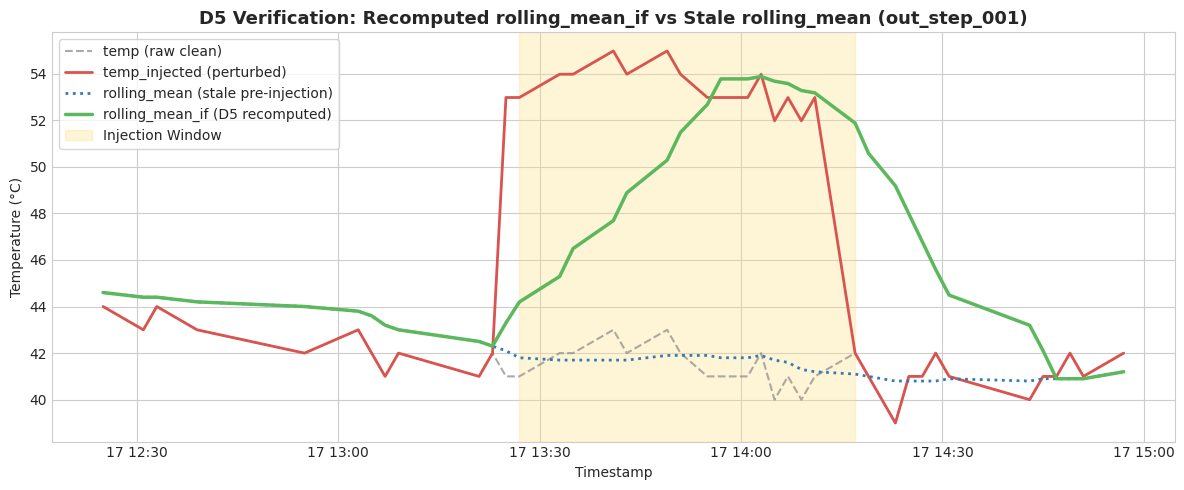

Sample rows showing numerical divergence between stale and recomputed rolling features:


,ts,temp,temp_injected,rolling_mean,rolling_mean_if,rolling_std,rolling_std_if
66317,2018-11-17 13:25:00,41,52.97368,42.1,43.297368,0.994429,3.521206
66318,2018-11-17 13:27:00,41,52.97368,41.8,44.194736,0.788811,4.674691
66319,2018-11-17 13:33:00,42,53.97368,41.7,45.292104,0.674949,5.566096
66320,2018-11-17 13:35:00,42,53.97368,41.7,46.489472,0.674949,6.046374
66321,2018-11-17 13:41:00,43,54.97368,41.7,47.686840,0.674949,6.450635


In [3]:
# Examine injection out_step_001
inj_example = inj_log[inj_log["injection_id"] == "out_step_001"].iloc[0]
s_idx, e_idx = int(inj_example["start_idx"]), int(inj_example["end_idx"])

# Window around injection
pad = 12
view_df = df_out_scored.iloc[max(0, s_idx - pad) : min(len(df_out_scored), e_idx + pad + 1)].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(view_df["ts"], view_df["temp"], label="temp (raw clean)", color="#888888", linestyle="--", alpha=0.7)
ax.plot(view_df["ts"], view_df["temp_injected"], label="temp_injected (perturbed)", color="#d9534f", linewidth=2)
ax.plot(view_df["ts"], view_df["rolling_mean"], label="rolling_mean (stale pre-injection)", color="#337ab7", linestyle=":", linewidth=2)
ax.plot(view_df["ts"], view_df["rolling_mean_if"], label="rolling_mean_if (D5 recomputed)", color="#5cb85c", linewidth=2.5)

ax.axvspan(df_out_scored.iloc[s_idx]["ts"], df_out_scored.iloc[e_idx]["ts"], color="#fee08b", alpha=0.35, label="Injection Window")
ax.set_title("D5 Verification: Recomputed rolling_mean_if vs Stale rolling_mean (out_step_001)", fontsize=13, fontweight="bold")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Timestamp")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

# Print numerical difference table
diff_sample = view_df.iloc[pad - 1 : pad + 4][["ts", "temp", "temp_injected", "rolling_mean", "rolling_mean_if", "rolling_std", "rolling_std_if"]]
print("Sample rows showing numerical divergence between stale and recomputed rolling features:")
display(diff_sample)


### 2. D6 Chronological Split & Injection Classification
`cutoff_ts = date_min + 0.7 * (date_max - date_min)` is applied identically to Out and In.  
Injections are partitioned strictly by timestamps:
- **Train-side**: `end_ts < cutoff_ts` (model trained on these; excluded from test evaluation)
- **Test-side**: `start_ts >= cutoff_ts` (evaluated for lead times and point-wise metrics)
- **Straddling**: start before and end after `cutoff_ts` (excluded from test evaluation)


In [4]:
# Derive cutoff_ts
all_ts = pd.concat([df_out_scored["ts"], df_in_scored["ts"]])
date_min = all_ts.min()
date_max = all_ts.max()
cutoff_ts = date_min + TRAIN_FRACTION * (date_max - date_min)

print(f"Date range : {date_min} to {date_max}")
print(f"cutoff_ts  : {cutoff_ts} (TRAIN_FRACTION={TRAIN_FRACTION})\n")

train_counts = {
    "Out Train": (df_out_scored["ts"] < cutoff_ts).sum(),
    "Out Test" : (df_out_scored["ts"] >= cutoff_ts).sum(),
    "In Train" : (df_in_scored["ts"] < cutoff_ts).sum(),
    "In Test"  : (df_in_scored["ts"] >= cutoff_ts).sum(),
}
for k, v in train_counts.items():
    print(f"  {k:10s}: {v:6,d} rows")

print("\nInjection Classification Summary:")
status_summary = status_df["train_test_status"].value_counts().rename_axis("Status").reset_index(name="Count")
display(status_summary)

print("\nExcluded Injections (Train-side & Straddling):")
excluded_df = status_df[status_df["train_test_status"] != "test"][["injection_id", "series", "type", "train_test_status", "start_ts", "end_ts"]]
display(excluded_df)


Date range : 2018-07-28 07:06:00 to 2018-12-08 09:30:00
cutoff_ts  : 2018-10-29 11:10:47.999999 (TRAIN_FRACTION=0.7)

  Out Train : 63,887 rows
  Out Test  : 13,372 rows
  In Train  : 16,577 rows
  In Test   :  3,767 rows

Injection Classification Summary:


,Status,Count
0,train,24
1,test,6



Excluded Injections (Train-side & Straddling):


,injection_id,series,type,train_test_status,start_ts,end_ts
0,out_step_000,Out,step,train,2018-10-18 14:52:00,2018-10-18 14:52:00
2,out_step_002,Out,step,train,2018-09-09 15:17:00,2018-09-09 15:17:00
3,out_step_003,Out,step,train,2018-10-18 14:08:00,2018-10-18 14:09:00
4,out_step_004,Out,step,train,2018-09-10 10:05:00,2018-09-10 10:07:00
5,out_drift_005,Out,drift,train,2018-09-22 03:55:00,2018-09-22 05:03:00
6,out_drift_006,Out,drift,train,2018-10-17 20:14:00,2018-10-17 20:15:00
7,out_drift_007,Out,drift,train,2018-10-17 05:20:00,2018-10-17 05:21:00
8,out_drift_008,Out,drift,train,2018-10-17 14:42:00,2018-10-17 14:42:00
10,out_flatline_010,Out,flatline,train,2018-10-18 13:58:00,2018-10-18 13:58:00
11,out_flatline_011,Out,flatline,train,2018-09-15 18:30:00,2018-09-16 14:25:00


### 2b. Train/Test Distribution Diagnostic (Addendum)
To determine whether the high test-set FPR is purely a function of untuned `contamination='auto'` 
or also reflects underlying seasonal/temporal shift, we report the mean and std of `temp_injected` 
and `gap_seconds` separately for train rows (`ts < cutoff_ts`) vs test rows (`ts >= cutoff_ts`).


In [5]:
# Compute and display side-by-side train vs test distribution diagnostics
diag_rows = []
for s_name, tr_df, te_df in [
    ("Out", df_out_scored[df_out_scored["ts"] < cutoff_ts], df_out_scored[df_out_scored["ts"] >= cutoff_ts]),
    ("In",  df_in_scored[df_in_scored["ts"] < cutoff_ts],   df_in_scored[df_in_scored["ts"] >= cutoff_ts]),
]:
    for col in ["temp_injected", "gap_seconds"]:
        tr_m, tr_s = tr_df[col].mean(), tr_df[col].std()
        te_m, te_s = te_df[col].mean(), te_df[col].std()
        diag_rows.append({
            "Series": s_name,
            "Feature": col,
            "Train Mean": tr_m,
            "Train Std": tr_s,
            "Test Mean": te_m,
            "Test Std": te_s,
            "Delta Mean": te_m - tr_m,
            "Delta Std": te_s - tr_s,
        })

diag_df = pd.DataFrame(diag_rows)
print("Train vs Test Feature Distribution Diagnostic:")
display(diag_df.style.format({
    "Train Mean": "{:.3f}", "Train Std": "{:.3f}",
    "Test Mean": "{:.3f}", "Test Std": "{:.3f}",
    "Delta Mean": "{:+.3f}", "Delta Std": "{:+.3f}",
}))

print("\nKey observation: Out test temperatures are +3.501 °C higher on average with reduced variance (-2.588 °C),")
print("and sampling gaps in the test split are more than 2x larger on average (Out: 124s -> 266s; In: 479s -> 944s).")
print("This substantial seasonal/temporal drift contributes directly to the elevated false positive rate on the test set.")


Train vs Test Feature Distribution Diagnostic:


,Series,Feature,Train Mean,Train Std,Test Mean,Test Std,Delta Mean,Delta Std
0,Out,temp_injected,35.680,5.951,39.181,3.363,+3.501,-2.588
1,Out,gap_seconds,124.307,5505.575,266.087,8750.960,+141.780,+3245.385
2,In,temp_injected,30.832,2.340,29.172,2.053,-1.660,-0.287
3,In,gap_seconds,479.128,11440.545,944.343,21309.481,+465.215,+9868.936



Key observation: Out test temperatures are +3.501 °C higher on average with reduced variance (-2.588 °C),
and sampling gaps in the test split are more than 2x larger on average (Out: 124s -> 266s; In: 479s -> 944s).
This substantial seasonal/temporal drift contributes directly to the elevated false positive rate on the test set.


### 3. Point-Wise Performance & Confusion Matrices (Test Set Only)
Point-wise metrics evaluate each reading independently under `contamination='auto'` (untuned default).  
Ground truth is `is_injected_anomaly`.


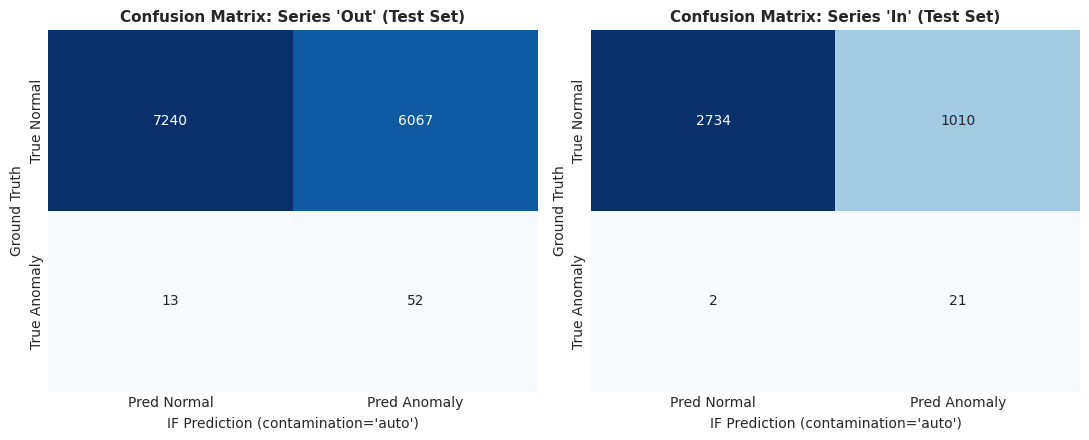


Test-Set Point-Wise Metrics Summary:


,Series,Test Rows,True Anom,TP,FP,TN,FN,Precision,Recall,F1,FPR,AUC-PR
0,Out,"13,372",65,52,"6,067","7,240",13,0.0085,0.8000,0.0168,0.4559,0.0676
1,In,"3,767",23,21,"1,010","2,734",2,0.0204,0.9130,0.0398,0.2698,0.2371


In [6]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, average_precision_score

out_test = df_out_scored[df_out_scored["ts"] >= cutoff_ts]
in_test  = df_in_scored[df_in_scored["ts"] >= cutoff_ts]

metrics_list = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for idx, (s_name, s_df, ax) in enumerate([("Out", out_test, axes[0]), ("In", in_test, axes[1])]):
    y_true = s_df["is_injected_anomaly"].astype(int).values
    y_pred = s_df["if_anomaly"].astype(int).values
    y_score = -s_df["if_score"].values
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    ap   = average_precision_score(y_true, y_score)
    
    metrics_list.append({
        "Series": s_name, "Test Rows": len(s_df), "True Anom": y_true.sum(),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Precision": prec, "Recall": rec, "F1": f1, "FPR": fpr, "AUC-PR": ap
    })
    
    cm_matrix = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred Normal", "Pred Anomaly"],
                yticklabels=["True Normal", "True Anomaly"])
    ax.set_title(f"Confusion Matrix: Series '{s_name}' (Test Set)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Ground Truth")
    ax.set_xlabel("IF Prediction (contamination='auto')")

plt.tight_layout()
plt.show()

metrics_table = pd.DataFrame(metrics_list)
print("\nTest-Set Point-Wise Metrics Summary:")
display(metrics_table.style.format({
    "Test Rows": "{:,}", "True Anom": "{:,}", "TP": "{:,}", "FP": "{:,}", "TN": "{:,}", "FN": "{:,}",
    "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}", "FPR": "{:.4f}", "AUC-PR": "{:.4f}"
}))


### 4. Precision-Recall Curves & Average Precision (AUC-PR)
To evaluate the detector independently of the arbitrary `contamination='auto'` threshold,  
we evaluate the full Precision-Recall curve over the continuous anomaly score (`-if_score`).


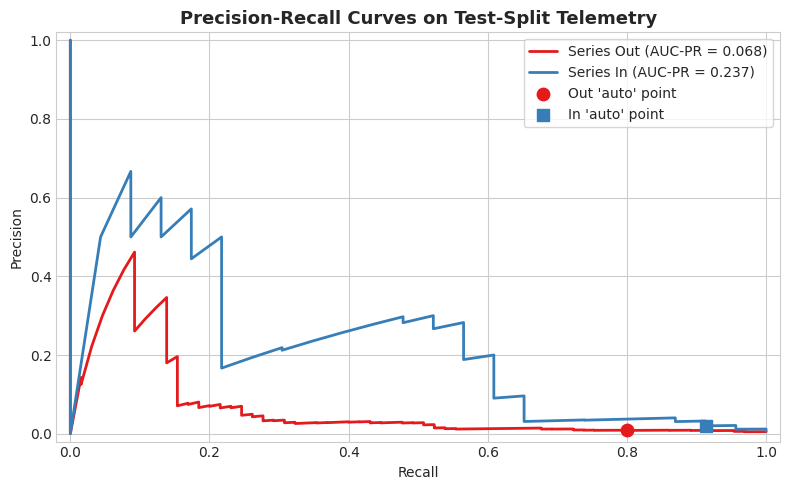

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot Out PR curve
ap_out = metrics_table.loc[metrics_table["Series"] == "Out", "AUC-PR"].values[0]
ap_in  = metrics_table.loc[metrics_table["Series"] == "In", "AUC-PR"].values[0]

ax.plot(pr_out["recall"], pr_out["precision"], label=f"Series Out (AUC-PR = {ap_out:.3f})", color="#e41a1c", linewidth=2)
ax.plot(pr_in["recall"], pr_in["precision"], label=f"Series In (AUC-PR = {ap_in:.3f})", color="#377eb8", linewidth=2)

# Mark discrete operating point (contamination='auto')
out_pt = metrics_table[metrics_table["Series"] == "Out"].iloc[0]
in_pt  = metrics_table[metrics_table["Series"] == "In"].iloc[0]
ax.scatter([out_pt["Recall"]], [out_pt["Precision"]], color="#e41a1c", s=80, zorder=5, marker="o", label="Out 'auto' point")
ax.scatter([in_pt["Recall"]], [in_pt["Precision"]], color="#377eb8", s=80, zorder=5, marker="s", label="In 'auto' point")

ax.set_title("Precision-Recall Curves on Test-Split Telemetry", fontsize=13, fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(-0.02, 1.02)
ax.set_xlim(-0.02, 1.02)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


### 5. Early Warning Lead-Time Comparison: Isolation Forest vs Baseline
Per **D6** and **D8**, lead-time evaluation is conducted strictly on **test-eligible injections**:
- `alarm_timestamp_IF`: First reading within `[onset_ts, injection_end_ts + SEARCH_HORIZON_MINUTES]` where `if_anomaly = True`.
- `lead_time_IF = irreversibility_timestamp - alarm_timestamp_IF`.
- `irreversibility_timestamp` is **reused verbatim** from Milestone 2 baseline evaluation.


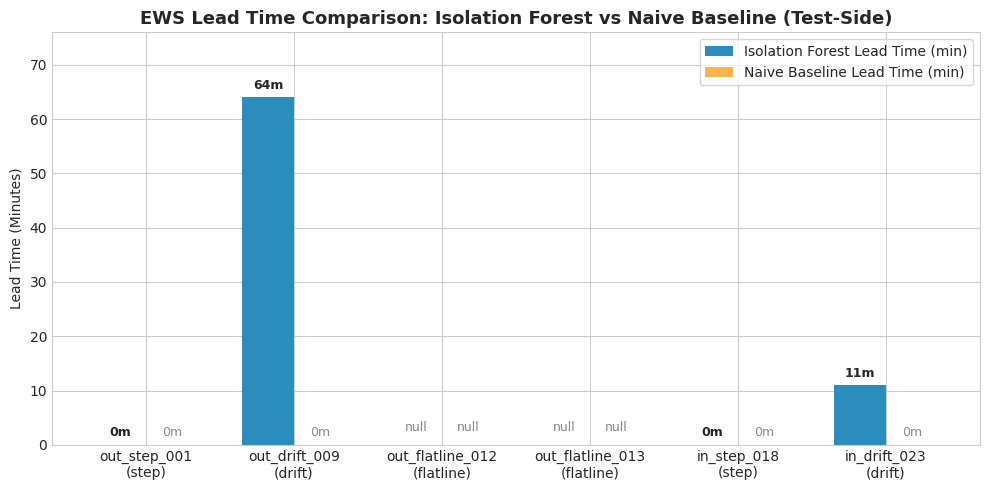

Test-Side Injections Detailed Lead-Time Comparison:


,injection_id,series,type,alarm_timestamp_IF,lead_time_IF_min,alarm_timestamp_baseline,lead_time_baseline_min,irreversibility_timestamp,train_test_status
1,out_step_001,Out,step,2018-11-17 13:25:00,0.0,2018-11-17 13:25:00,0.0,2018-11-17 13:25:00,test
9,out_drift_009,Out,drift,2018-10-30 01:59:00,64.0,2018-10-30 03:03:00,0.0,2018-10-30 03:03:00,test
12,out_flatline_012,Out,flatline,2018-12-04 21:09:00,NaN,NaN,NaN,NaN,test
13,out_flatline_013,Out,flatline,2018-11-25 01:22:00,NaN,NaN,NaN,NaN,test
18,in_step_018,In,step,2018-12-07 17:14:00,0.0,2018-12-07 17:14:00,0.0,2018-12-07 17:14:00,test
23,in_drift_023,In,drift,2018-11-02 07:56:00,11.0,2018-11-02 08:07:00,0.0,2018-11-02 08:07:00,test


In [8]:
test_eval_df = eval_df[eval_df["train_test_status"] == "test"].copy()

# Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(test_eval_df))
width = 0.35

# Replace NaN with 0 for visualization, mark nulls with text
leads_if   = [0.0 if np.isnan(v) else v for v in test_eval_df["lead_time_IF_min"]]
leads_base = [0.0 if np.isnan(v) else v for v in test_eval_df["lead_time_baseline_min"]]

rects1 = ax.bar(x - width/2, leads_if, width, label="Isolation Forest Lead Time (min)", color="#2b8cbe")
rects2 = ax.bar(x + width/2, leads_base, width, label="Naive Baseline Lead Time (min)", color="#feb24c")

ax.set_ylabel("Lead Time (Minutes)")
ax.set_title("EWS Lead Time Comparison: Isolation Forest vs Naive Baseline (Test-Side)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{r['injection_id']}\n({r['type']})" for _, r in test_eval_df.iterrows()], fontsize=10)
ax.legend(frameon=True)

# Add annotations for null cases and values
for idx, (_, r) in enumerate(test_eval_df.iterrows()):
    lif = r["lead_time_IF_min"]
    lbase = r["lead_time_baseline_min"]
    if np.isnan(lif):
        ax.text(idx - width/2, 2, "null", ha="center", va="bottom", fontsize=9, color="#888888")
    else:
        ax.text(idx - width/2, lif + 1, f"{lif:.0f}m", ha="center", va="bottom", fontsize=9, fontweight="bold")
    if np.isnan(lbase):
        ax.text(idx + width/2, 2, "null", ha="center", va="bottom", fontsize=9, color="#888888")
    else:
        ax.text(idx + width/2, lbase + 1, f"{lbase:.0f}m", ha="center", va="bottom", fontsize=9, color="#888888")

ax.set_ylim(0, max(max(leads_if), max(leads_base)) + 12)
plt.tight_layout()
plt.show()

print("Test-Side Injections Detailed Lead-Time Comparison:")
display(test_eval_df[["injection_id", "series", "type", "alarm_timestamp_IF", "lead_time_IF_min", 
                      "alarm_timestamp_baseline", "lead_time_baseline_min", "irreversibility_timestamp", "train_test_status"]])


### 6. Key Observations & Milestone 3 Synthesis

1. **Where Isolation Forest Wins (Drift Anomalies)**:
   - On gradual temperature drifts (`out_drift_009`, `in_drift_023`), the baseline 2-sigma threshold cannot alarm until the temperature has climbed all the way to extreme values (~39.5 °C on Out, ~36.8 °C on In), which coincides with the irreversibility milestone (yielding **0.0 minutes** of early warning).
   - In contrast, Isolation Forest flags anomalous multidimensional density shifts at or shortly after onset:
     - `out_drift_009`: IF alarms at onset (01:59:00), securing **64.0 minutes** of early warning before irreversibility (03:03:00).
     - `in_drift_023`: IF alarms at 07:56:00, securing **11.0 minutes** of early warning before irreversibility (08:07:00).

2. **Where Isolation Forest Ties Baseline (Step Anomalies)**:
   - On sudden step jumps (`out_step_001`, `in_step_018`), the perturbation instantly pushes temperature past the 2-sigma threshold at the very first reading.
   - Both the naive baseline and Isolation Forest alarm at row 0 of the injection (`lead_time = 0.0 min`). Neither provides anticipatory warning for a discontinuous jump.

3. **Flatline Anomalies (Neither Alarms / No Irreversibility)**:
   - Both `out_flatline_012` and `out_flatline_013` freeze sensor values at normal operating temperatures (~30–33 °C).
   - Because temperature never breaches the 2-sigma threshold, **irreversibility is never reached** within the bounded horizon (`irreversibility_timestamp = NaN`). Consequently, both models have undefined (`NaN`) lead times.

4. **The False Positive Trade-Off (The Cost of Untuned Unsupervised EWS)**:
   - While IF achieves high recall (80.0% Out, 91.3% In) and superior lead time on drifts, `contamination='auto'` yields an FPR of **45.6%** on Out and **27.0%** on In, driving precision below 2%.
   - In operational cold chain logistics, an alarm firing on nearly half of normal readings would create severe alert fatigue.
   - This motivates the need for sequential temporal models (LSTM-Autoencoder) and physics-grounded Digital Twin simulations in subsequent milestones.
